# FeatureSelection:

`sklearn.feature_selection` module has useful APIs to select features/ reduce dimensionality, either to improve estimators’ accuracy scores or to boost their performance on very high-dimensional datasets.

## Filter based Methods:
### VarianceThreshold

This transformer helps to keep only high variance features by providing a certain threshold.

> Features with variance greater or equal to threshold value are kept rest are removed.

> By default it removes any feature with same value i.e. 0 variance.

In [2]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction import DictVectorizer


data = [{'age': 4, 'height':96.0},
        {'age': 1, 'height':73.9},
        {'age': 3, 'height':88.9},
        {'age': 2, 'height':81.6}]

dv = DictVectorizer(sparse=False)
data_transformed = dv.fit_transform(data)
np.var(data_transformed, axis = 0)

array([ 1.25 , 67.735])

In [3]:
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold = 9)
data_new = vt.fit_transform(data_transformed)
data_new

array([[96. ],
       [73.9],
       [88.9],
       [81.6]])

As you may observe from output of above cell, the transformer has removed the `age` feature because its variance is below the threshold.
### SelectKBest

It selects `k` highest scoring features based on a function and removes the rest of the features.

Lets take an example of California Housing dataset.

In [4]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, mutual_info_regression
# dowload data
X_california, y_california = fetch_california_housing(return_X_y=True)
# select a subset of data
X, y = X_california[:2000, :], y_california[:2000]
print(f'Shape of of feature matrix before feature selection:{X.shape}')

Shape of of feature matrix before feature selection:(2000, 8)


Let's select 3 most important features, since it is a regression problem, we can use only `mutual_info_regression` or `f_regression` scoring functions only.

In [5]:
skb = SelectKBest(mutual_info_regression, k=3)
X_new = skb.fit_transform(X, y)
print("Shape of feature matrix after feature selection:", X_new.shape)
print("Selected features:", skb.get_feature_names_out())

Shape of feature matrix after feature selection: (2000, 3)
Selected features: ['x0' 'x6' 'x7']


### SelectPercentile

This is very similar to `SelectKBest` from previous section, the only difference is, it selects top `percentile` of all features and drops the rest of the features.

Similar to `SelectKBest`, it also uses a scoring function to decide importance of features.

Let's use the california housing price dataset for this API.

In [6]:
from sklearn.feature_selection import SelectPercentile

sp = SelectPercentile(mutual_info_regression, percentile = 30)
X_new = sp.fit_transform(X, y)
print("Shape of feature matrix after SelectPercentile:", X_new.shape)
print("Selected features:", sp.get_feature_names_out())

Shape of feature matrix after SelectPercentile: (2000, 3)
Selected features: ['x0' 'x6' 'x7']


### GenericUnivariateSelect
It applies univariate feature selection with a certain strategy, which is passed to the API via `mode` parameter. The `mode` can take one of the following values: `percentile` (top percentage), `k_best` (top k), `fpr` (false positive rate), `fdr`(false discovery rate), `fwe` (family wise error rate).


If we want to accomplish the same objective as `SelectKBest`, we can use following code:

In [7]:
from sklearn.feature_selection import GenericUnivariateSelect

gus = GenericUnivariateSelect(mutual_info_regression, mode = "k_best", param = 3)
X_new = gus.fit_transform(X, y)
print("Shape of feature matrix after GenericUnivariateSelect using k best:", X_new.shape)
print("Selected features:", gus.get_feature_names_out())

Shape of feature matrix after GenericUnivariateSelect using k best: (2000, 3)
Selected features: ['x0' 'x6' 'x7']


## Wrapper Based Methods:
### RFE (RecursiveFeatureElimination)

* **STEP 1**: Fits a model and
* **STEP 2**: Ranks the features, afterwards it removes one or more features (depending upon `step` parameter).

These two steps are repeated until desired number of features are selected.

In [8]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

estimator = LinearRegression()
selector = RFE(estimator, n_features_to_select = 3, step = 1)
selector = selector.fit(X, y)

# support_ attribute is a boolean array, marking which features are selected
print(selector.support_)

# selector.ranking_ gives the rank of each feature
# features with rank 1 are selected and from rank 2 onwards are ranked least
print("Ranks of features:", selector.ranking_)

X_new = selector.transform(X)
print("Shape after using RFE:", X_new.shape)

[ True False False False False False  True  True]
Ranks of features: [1 5 4 3 6 2 1 1]
Shape after using RFE: (2000, 3)


### RFE-CV

This adds another layer of cross validation to `RFE`.

### SelectFromModel
>  Selects desired number of important features (as specified with `max_features` parameter) above certain threshold of feature importance as obtained from the trained estimator.

* The feature importance is obtained via `coef_`, `feature_importances_` or an `importance_getter` callable from the trained estimator.

* The feature importance threshold can be specified either numerically or through string argument based on built-in heuristics such as `mean`, `median` and float multiples of these like `0.1*mean`.

In [9]:
from sklearn.feature_selection import SelectFromModel

estimator = LinearRegression()

estimator.fit(X, y)

print("Coeff of features:", estimator.coef_)
print("Indices of top three features:", np.argsort(estimator.coef_)[-3:])

t=np.argsort(np.abs(estimator.coef_))[-3:]
model = SelectFromModel(estimator, max_features=3, prefit=True)
X_new = model.transform(X)

print("Shape after SelectFromModel:", X_new.shape)

Coeff of features: [ 3.64048292e-01  5.56221906e-03  5.13591243e-02 -1.64474348e-01
  5.90411479e-05 -1.64573915e-01 -2.17724525e-01 -1.85343265e-01]
Indices of top three features: [1 2 0]
Shape after SelectFromModel: (2000, 3)


### SequentialFeatureSelection

It performs feature selection by selecting or deselecting features one by one in a greedy manner.

In [10]:
%%time

from sklearn.feature_selection import SequentialFeatureSelector

estimator = LinearRegression()

sfs = SequentialFeatureSelector(estimator, n_features_to_select = 3)
sfs.fit_transform(X, y)

print(sfs.get_support())


[ True False False False False  True  True False]
CPU times: user 355 ms, sys: 2.44 ms, total: 357 ms
Wall time: 280 ms


The features corresponding to `True` in the output `sfs.get_support()` are selected.  In this case, feature 1, 6 and 7 are selected.

In [11]:
%%time

estimator = LinearRegression()

sfs = SequentialFeatureSelector(estimator, n_features_to_select = 3, direction="backward")
sfs.fit_transform(X, y)

print(sfs.get_support())

[ True False False False False  True  True False]
CPU times: user 641 ms, sys: 2.06 ms, total: 643 ms
Wall time: 419 ms


A couple of observations:
* Both `forward` and `backward` selection methods select the same features.
* The `backward` selection method takes longer than `forward` selection method.

### PCA
PCA is used to decompose a multivariate dataset in a set of successive orthogonal components that capture maximum amount of the variance.

It helps in reducing dimensions of a dataset, thus computational cost of next steps e.g. training a model, cross validation etc.


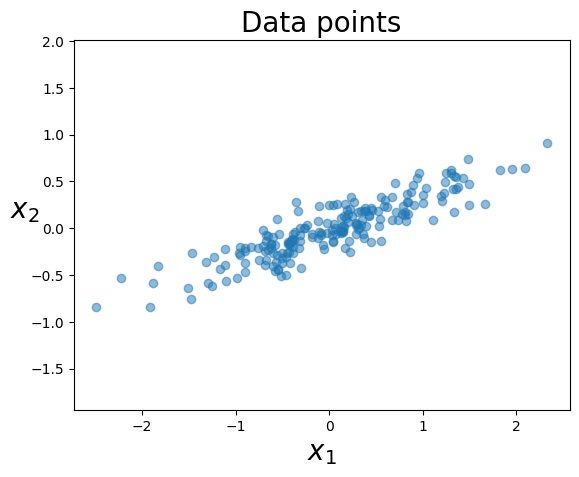

In [12]:
import matplotlib.pyplot as plt

#@title [Generate synthetic dataset]
rand = np.random.RandomState(1)
X = np.dot(rand.rand(2, 2), rand.randn(2, 200)).T

plt.figure()
plt.title('Data points', size = 20)

# set x and y labels
plt.xlabel('$x_1$', size=20)
plt.ylabel('$x_2$', size=20, rotation = 0)

# plot the data points
plt.scatter(X[:, 0], X[:, 1], alpha=0.5)
plt.axis('equal');

In [13]:
# lets fit PCA transformer on this data.

from sklearn.decomposition import PCA

pca = PCA(n_components = 2)

pca.fit(X)

PCA(n_components=2)

In [14]:
print("The first 2 components are:", pca.components_)
print("Explained variance by each components:", pca.explained_variance_)
print("Mean across x1, and x2 dimensions are:", pca.mean_)

The first 2 components are: [[ 0.94446029  0.32862557]
 [-0.32862557  0.94446029]]
Explained variance by each components: [0.7625315 0.0184779]
Mean across x1, and x2 dimensions are: [ 0.03351168 -0.00408072]


To better understand PCA, lets visualize these principal axes.

* There are two principal axes $C_1$ and $C_2$. They are orthogonal to
each other. An additional vector $C_3$ is also mentioned for comparison.

* The lengths of $C_1$ and $C_2$ are taken as square root of respective explanined variance. the length of the vector implies how important that
vector is.

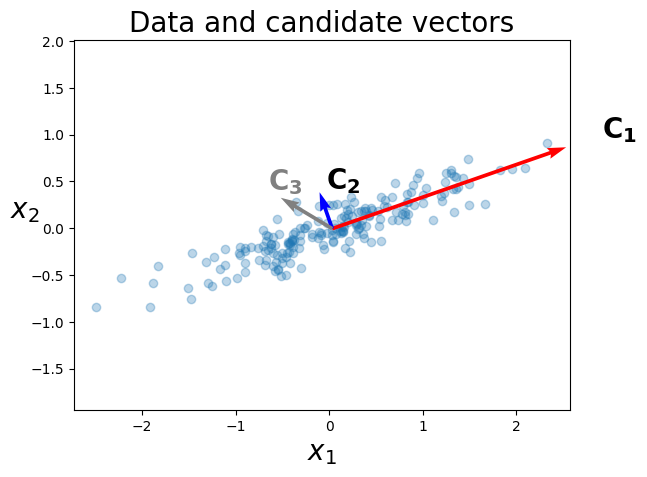

In [15]:

#@title [Visualize principal components]
# set x and y labels
plt.figure()
plt.title('Data and candidate vectors', size = 20)
plt.xlabel('$x_1$', size=20)
plt.ylabel('$x_2$', size=20, rotation = 0)

# plot data points
plt.scatter(X[:, 0], X[:, 1], alpha=0.3)

for length, principal_axis, axis_name, i_color in zip(pca.explained_variance_,
                                    pca.components_,
                                    ['$\mathbf{C_1}$','$\mathbf{C_2}$'],
                                    ['r','b']):
    v = principal_axis * np.sqrt(length)
    v0, v1 = pca.mean_, pca.mean_ + v

    # draw principal axis
    plt.quiver(*v0,*(v1-v0),scale=0.33, scale_units='xy', color=i_color)

    # label the  principal axis
    plt.text(*(3.4*v1), axis_name, size = 20)

# draw 3rd component
lengths = np.eye(2)
np.fill_diagonal(lengths, np.sqrt(pca.explained_variance_))

c3 = pca.mean_+[-0.5,0.3]

plt.quiver(*pca.mean_,
           *(1.1*(c3-pca.mean_)),
           scale=1,
           scale_units='xy',
           color='grey')

# label the  principal axis
plt.text(*(1.4*c3),
         '$\mathbf{C_3}$',
         size = 20,
         color='grey')

plt.axis('equal')
plt.show()

In [16]:
# draw projections of data points on different vectors
projections = X@pca.components_
print(projections.shape)

arbitary_projection = X@c3
print(arbitary_projection.shape)

(200, 2)
(200,)


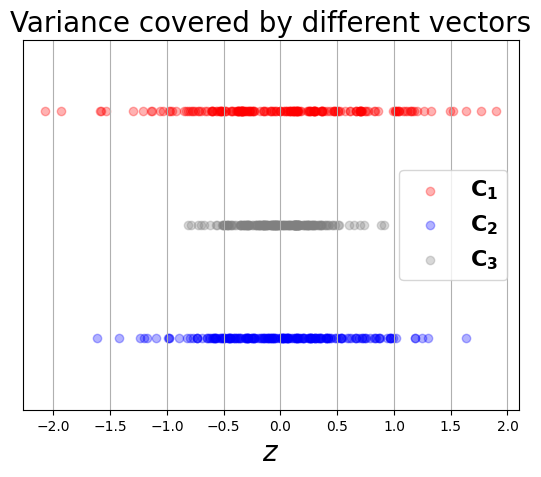

In [17]:
# plt.figure(figsize=(8,6))
plt.scatter(projections[:,0], 1+np.zeros((200,1)),  alpha = 0.3, color='r')
plt.scatter(projections[:,1], -1+np.zeros((200,1)),  alpha = 0.3, color='b')
plt.scatter(arbitary_projection,np.zeros((200,)),  alpha = 0.3, color='grey')
plt.legend(['$\mathbf{C_1}$', '$\mathbf{C_2}$','$\mathbf{C_3}$'], prop={'size' : 16})
plt.title("Variance covered by different vectors", size = 20)
plt.ylim([-1.5,1.5])
plt.axis('equal')
plt.grid(True)
plt.yticks([],[])
plt.xlabel('$z$', size = 20)
plt.show()

### Reducing dimensions
We can use PCA to reduce number of dimensions of a dataset. The components that are least important i.e. their explained variance is low, are removed and only those components that capture  high (i.e. desired) amount of variance are kept.


In [18]:
pca = PCA(n_components=1)
pca.fit(X)
X_pca = pca.transform(X)
print("original shape:   ", X.shape)
print("transformed shape:", X_pca.shape)

original shape:    (200, 2)
transformed shape: (200, 1)


To better understand what happend to our data, let's visualize our original data and the reduced data.

To do this, we will need to bring the transformed data into space of original data, which can be accomplished by `inverse_transform` methond of `PCA` object.

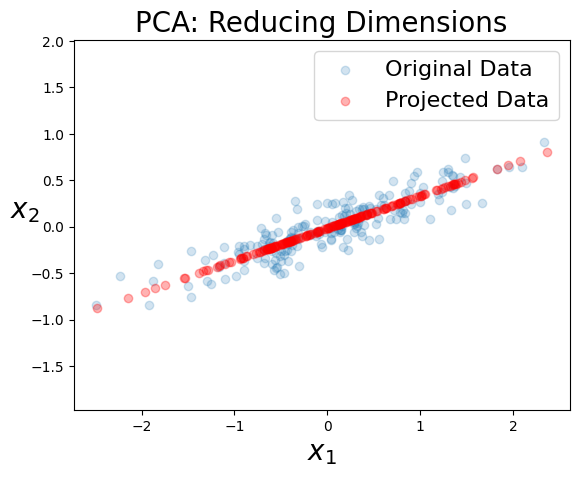

In [19]:
#@title [Visualize data in PC space]
# inverse transform the reduced data
X_new = pca.inverse_transform(X_pca)

plt.figure()
plt.title('PCA: Reducing Dimensions', size = 20)
plt.xlabel('$x_1$', size=20)
plt.ylabel('$x_2$', size=20, rotation = 0)

plt.scatter(X[:, 0], X[:, 1], alpha=0.2)
plt.scatter(X_new[:, 0], X_new[:, 1], alpha=0.3, c='r')
plt.legend(['Original Data', 'Projected Data'], prop={'size' : 16})
plt.axis('equal')
plt.show()

# **12. Chaining Transformers**

The preprocessing transformations are applied one after another on the input feature matrix.

> It is important to apply exactly same transformation on training, evaluation and test set in the same order.

Failing to do so would lead to incorrect predictions from model due to distribution shift and hence incorrect performance evaluation.

The `sklearn.pipeline` module provides utilities to build a composite estimator, as a chain of transformers and estimators.

## Pipeline

Sequentially apply a list of transformers and estimators.
*  Intermediate steps of the pipeline must be ‘transformers’ that is, they must implement `fit` and `transform` methods.
*  The final estimator only needs to implement `fit`.

The purpose of the pipeline is to assemble several steps that can be cross-validated together while setting different parameters.

#### Creating pipelines

A pipeline can be created with `Pipeline()`.
It takes a list of `('estimatorName'`, `estimator(...))` tuples. The pipeline object exposes interface of the last step.

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

estimators = [
    ("imputer", SimpleImputer()),
    ("pca", PCA),
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression),
]

pipe = Pipeline(steps=estimators)

print(len(pipe.steps))
print(pipe.steps)

4
[('imputer', SimpleImputer()), ('pca', <class 'sklearn.decomposition._pca.PCA'>), ('scaler', StandardScaler()), ('regressor', <class 'sklearn.linear_model._base.LinearRegression'>)]


### Grid Search with pipeline

By using naming convention of nested parameters, grid search can implemented.

In [21]:
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = dict(imputer=['passthrough',
                           SimpleImputer(),
                           KNNImputer()],
                  clf=[SVC(), LogisticRegression()],
                  clf__C=[0.1, 10, 100])
grid_search = GridSearchCV(pipe, param_grid=param_grid)

* `C` is an inverse of regularization, lower its value stronger the regularization is.

* In the example above `clf__C` provides a set of values for grid search.

### Caching transformers

Transforming data is a computationally expensive step.

* For grid search, transformers need not be applied for every parameter configuration. They can be applied only once, and the transformed data can reused.

This can be achieved by setting `memory` parameter of a `pipeline` object.




In [22]:
import tempfile
tempDirPath = tempfile.TemporaryDirectory()

estimators = [
  ('simpleImputer', SimpleImputer()),
  ('pca', PCA(2)),
  ('regressor', LinearRegression())
]
pipe = Pipeline(steps=estimators, memory = tempDirPath)

## FeatureUnion

Concatenates results of multiple transformer objects.

* Applies a list of transformer objects in parallel, and their outputs are concatenated side-by-side into a larger matrix.

`FeatureUnion` and `Pipeline` can be used to create complex transformers.

## Visualizing pipelines

In [23]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([('selector',ColumnTransformer([('select_first_4',
                                                         'passthrough',
                                                         slice(0,4))])),
                         ('imputer', SimpleImputer(strategy="median")),
                         ('std_scaler', StandardScaler()),
                        ])
cat_pipeline = ColumnTransformer([('label_binarizer', LabelBinarizer(),[4]),
                                  ])
full_pipeline = FeatureUnion(transformer_list=
                             [("num_pipeline", num_pipeline),
                              ("cat_pipeline", cat_pipeline),
                             ])

In [25]:
from sklearn import set_config
set_config(display='diagram')
# displays HTML representation in a jupyter context
full_pipeline

FeatureUnion(transformer_list=[('num_pipeline',
                                Pipeline(steps=[('selector',
                                                 ColumnTransformer(transformers=[('select_first_4',
                                                                                  'passthrough',
                                                                                  slice(0, 4, None))])),
                                                ('imputer',
                                                 SimpleImputer(strategy='median')),
                                                ('std_scaler',
                                                 StandardScaler())])),
                               ('cat_pipeline',
                                ColumnTransformer(transformers=[('label_binarizer',
                                                                 LabelBinarizer(),
                                                                 [4])]))])

## Handling imbalanced data

Imbalanced datasets are those where one class is very less represented than the other class. This kind of data results in less efficient ML algorithms.

There are two main approaches to handle imbalanced data:

*    Undersampling
*    Oversampling



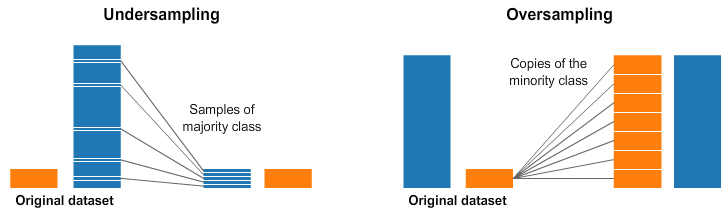

We will demonstrate how to handle imbalance with the help of wine quality dataset that we have used earlier in this notebook.

We will reload this dataset once more before using it for the demonstration.

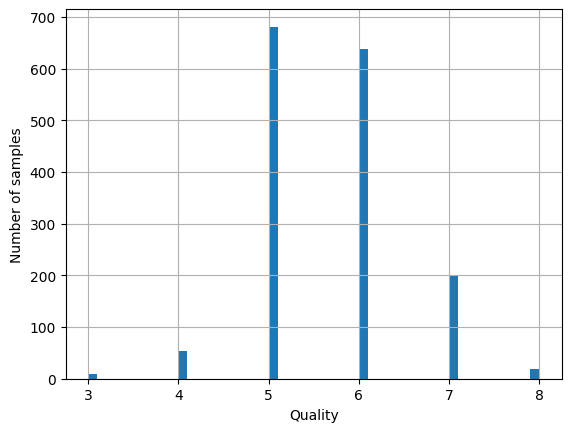

In [26]:
wine_data = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/"
    "winequality-red.csv",
    sep=";")

# display the histogram of the target variable 'quality'
wine_data['quality'].hist(bins=50)
plt.xlabel('Quality')
plt.ylabel('Number of samples')
plt.show()

### Under Sampling
Undersampling refers to sampling from the majority class in order to keep only a part of these data points.

It may be carried out using **RandomUnderSampler** class from **imblearn** library.


In [28]:
from imblearn.under_sampling import RandomUnderSampler

# class count
class_count_3, class_count_4, class_count_5, class_count_6, class_count_7, class_count_8 = wine_data['quality'].value_counts()

# Separate class
class_3 = wine_data[wine_data['quality'] == 3]
class_4 = wine_data[wine_data['quality'] == 4]
class_5 = wine_data[wine_data['quality'] == 5]
class_6 = wine_data[wine_data['quality'] == 6]
class_7 = wine_data[wine_data['quality'] == 7]
class_8 = wine_data[wine_data['quality'] == 8]


# print the shape of the class
print('class 3:', class_3.shape)
print('class 4:', class_4.shape)
print('class 5:', class_5.shape)
print('class 6:', class_6.shape)
print('class 7:', class_7.shape)
print('class 8:', class_8.shape)


class 3: (10, 12)
class 4: (53, 12)
class 5: (681, 12)
class 6: (638, 12)
class 7: (199, 12)
class 8: (18, 12)


In [29]:
from collections import Counter #It allows you to count the items in an iterable list.

X = wine_data.drop(['quality'], axis=1)
y = wine_data['quality']

undersample = RandomUnderSampler(random_state=0,)
X_rus, y_rus = undersample.fit_resample(X,y)

print('original dataset shape:', Counter(y))
print('Resample dataset shape', Counter(y_rus))

original dataset shape: Counter({5: 681, 6: 638, 7: 199, 4: 53, 8: 18, 3: 10})
Resample dataset shape Counter({3: 10, 4: 10, 5: 10, 6: 10, 7: 10, 8: 10})


The class with the least number of samples is '3'. Hence all the other class samples are reduced to the number of samples in the least class.

### Over Sampling
Oversampling refers to replicating some points from the minority class in order to increase the cardinality of the minority class. This might consist of either replicating or generating synthetic data for the minority class.

It may be carried out using **RandomOverSampler** class from **imblearn** library.

In [31]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler()
X_ros, y_ros = ros.fit_resample(X, y)

print('original dataset shape:', Counter(y))
print('Resample dataset shape', Counter(y_ros))

print(X_ros.shape[0] - X.shape[0], 'New random points generated with RandomOverSampler')

original dataset shape: Counter({5: 681, 6: 638, 7: 199, 4: 53, 8: 18, 3: 10})
Resample dataset shape Counter({5: 681, 6: 681, 7: 681, 4: 681, 8: 681, 3: 681})
2487 New random points generated with RandomOverSampler


The class with the majority number of samples is '5'. Hence all the other class samples that are lesser than this class count are newly sampled to the number of samples in the majority class.

#### Oversampling using SMOTE
SMOTE (Synthetic Minority Oversampling Technique) is a popular technique for oversampling.  It is available under **imblearn** library.


In [33]:
from imblearn.over_sampling import SMOTE
oversample = SMOTE()
X_sm, y_sm = oversample.fit_resample(X, y)
counter = Counter(y_sm)
counter

Counter({5: 681, 6: 681, 7: 681, 4: 681, 8: 681, 3: 681})

In [34]:
print(X_sm.shape[0] - X.shape[0], 'New random points generated with SMOTE')

2487 New random points generated with SMOTE


**Types of SMOTE:**
*   Borderline SMOTE
*   Borderline-SMOTE SVM
*   Adaptive Synthetic Sampling (ADASYN)